In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("Customer_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df_clean=df.copy()
print(df_clean.shape)
df_clean.head()

(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [ ]:
num_col=df.select_dtypes(include=['float64','int64'])
num_col

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


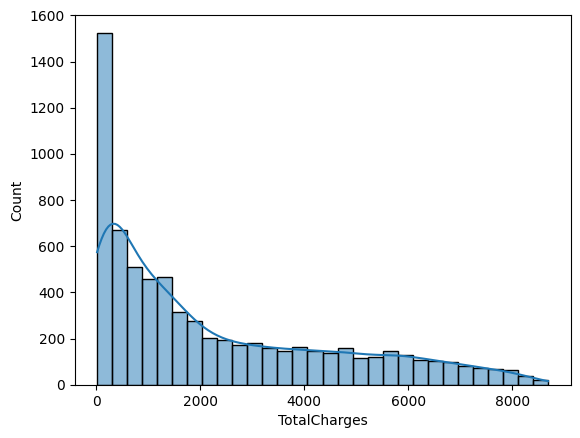

In [ ]:
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.show()

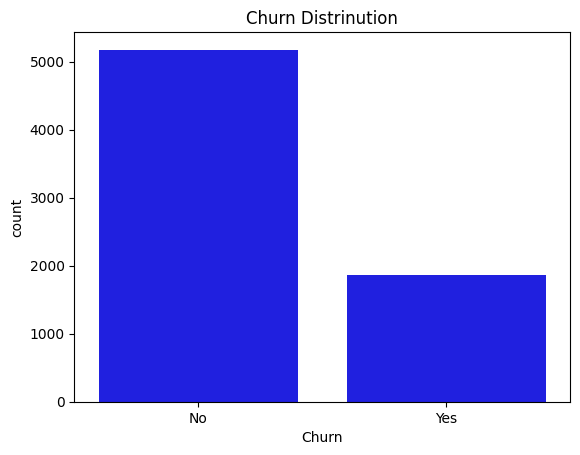

In [ ]:
sns.countplot(df, x='Churn', color='blue')
plt.title("Churn Distrinution")
plt.show()

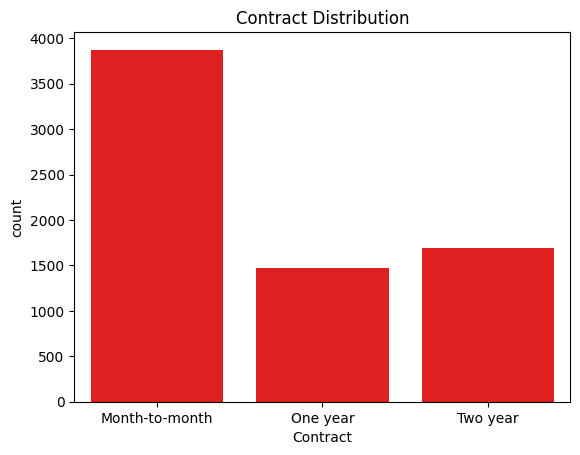

In [ ]:
sns.countplot(df, x='Contract', color='red')
plt.title("Contract Distribution")
plt.show()

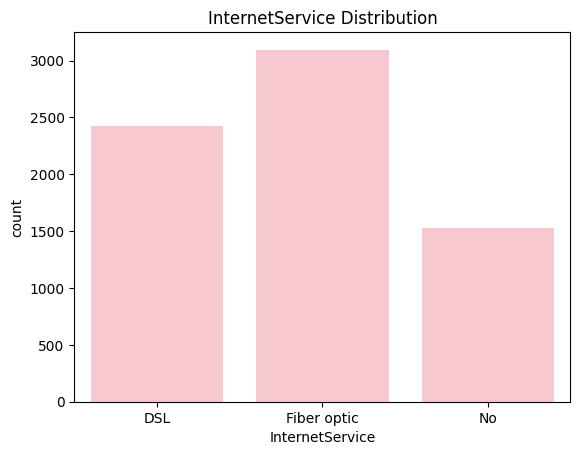

In [ ]:
sns.countplot(df, x='InternetService', color='pink')
plt.title("InternetService Distribution")
plt.show()

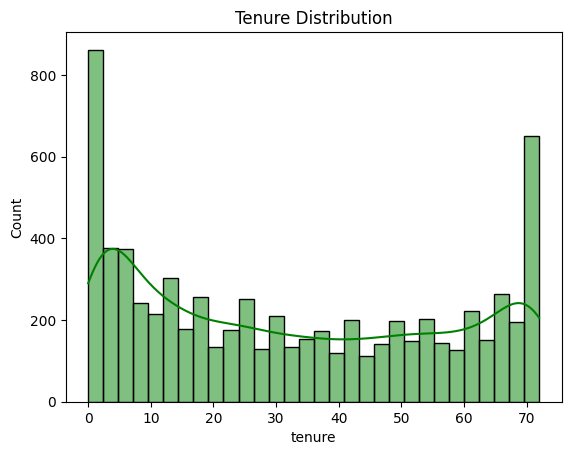

In [ ]:
sns.histplot(df['tenure'], bins=30, kde=True, color='green')
plt.title("Tenure Distribution")
plt.show()

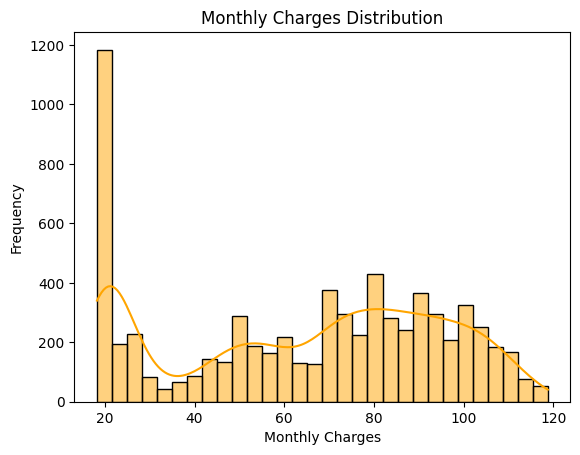

In [ ]:
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color="orange")
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

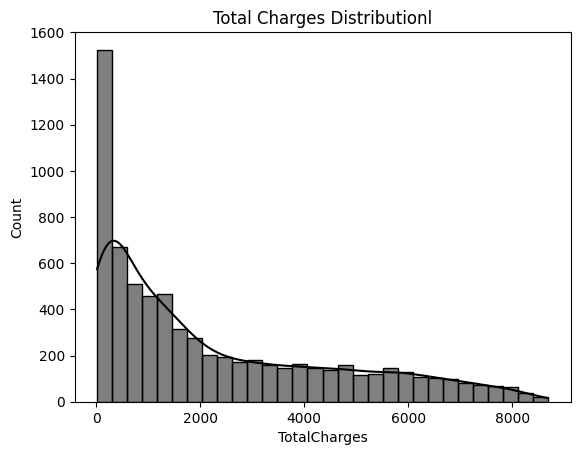

In [ ]:
sns.histplot(df["TotalCharges"],bins=30, kde= True,color="black")
plt.title("Total Charges Distributionl")
plt.show()

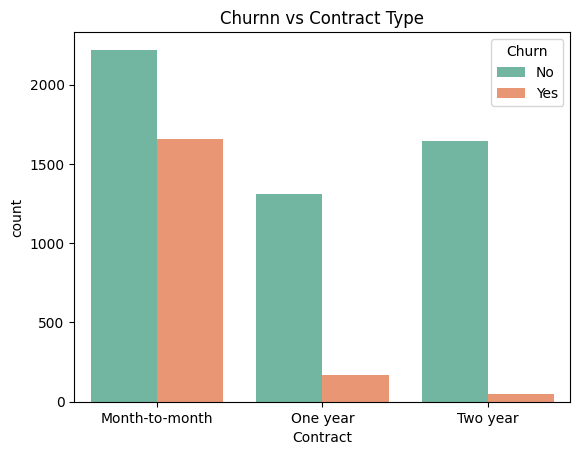

In [ ]:
sns.countplot(df, x='Contract', hue='Churn', palette='Set2')
plt.title("Churnn vs Contract Type")
plt.show()

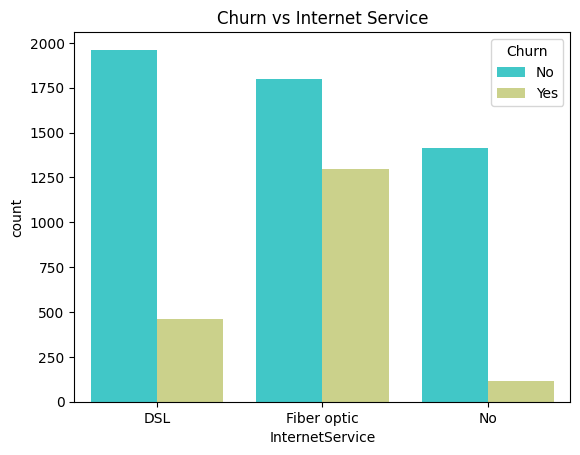

In [ ]:
sns.countplot(df, x='InternetService', hue='Churn', palette='rainbow')
plt.title("Churn vs Internet Service")
plt.show()

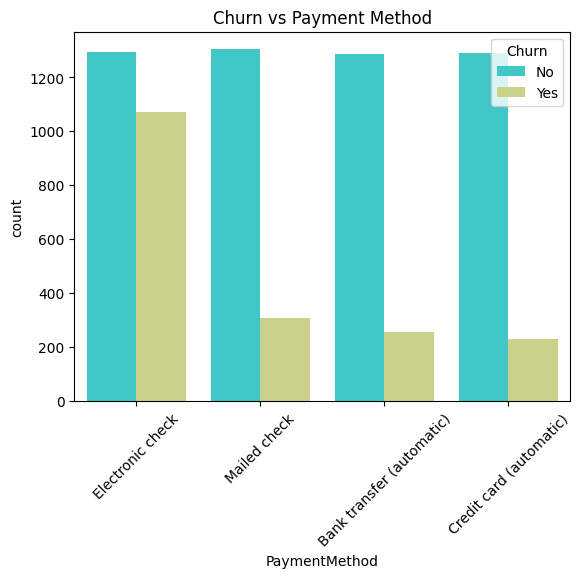

In [ ]:
sns.countplot(df, x='PaymentMethod', hue='Churn', palette='rainbow')
plt.title("Churn vs Payment Method")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3085/128038975.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x='Churn', y='MonthlyCharges', palette='viridis')


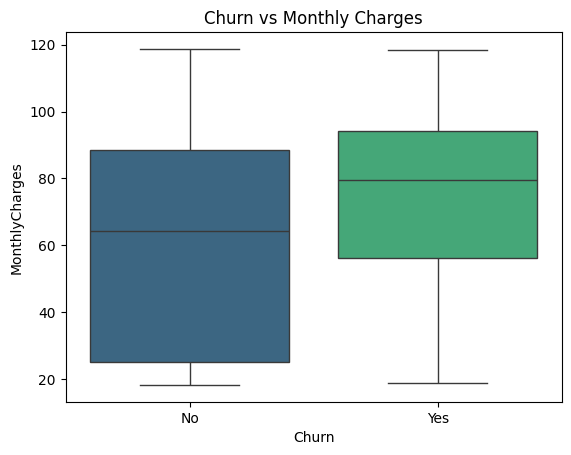

In [ ]:
sns.boxplot(df, x='Churn', y='MonthlyCharges', palette='viridis')
plt.title("Churn vs Monthly Charges")
plt.show()

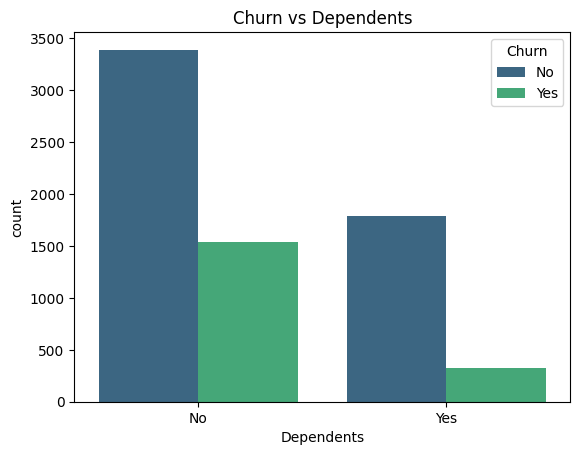

In [ ]:
sns.countplot(df, x='Dependents', hue="Churn", palette='viridis')
plt.title("Churn vs Dependents")
plt.show()

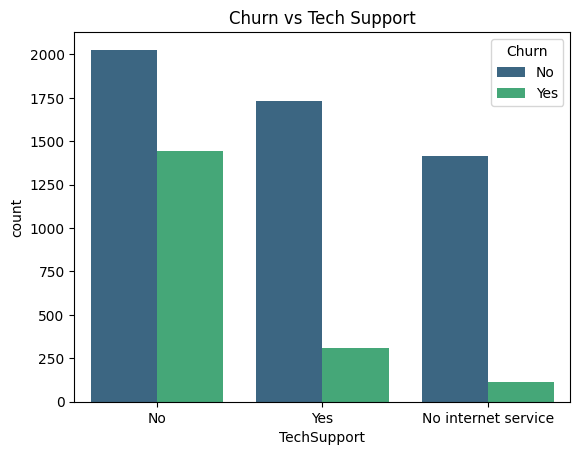

In [ ]:
sns.countplot(df, x='TechSupport', hue='Churn', palette='viridis')
plt.title("Churn vs Tech Support")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

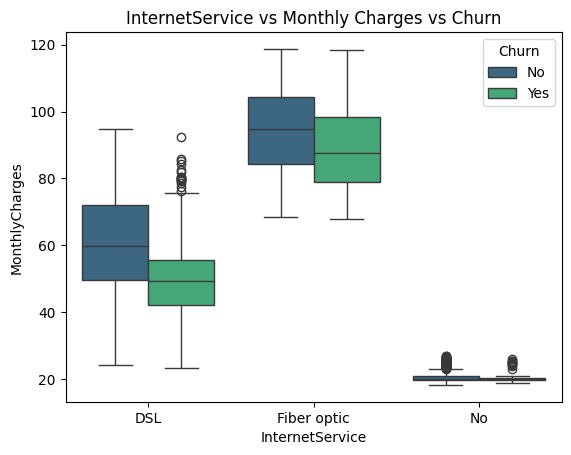

In [ ]:
sns.boxplot(df, x='InternetService', y='MonthlyCharges', hue='Churn', palette='viridis')
plt.title("InternetService vs Monthly Charges vs Churn")
plt.show

Before: (7043, 21)
After: (6701, 21)


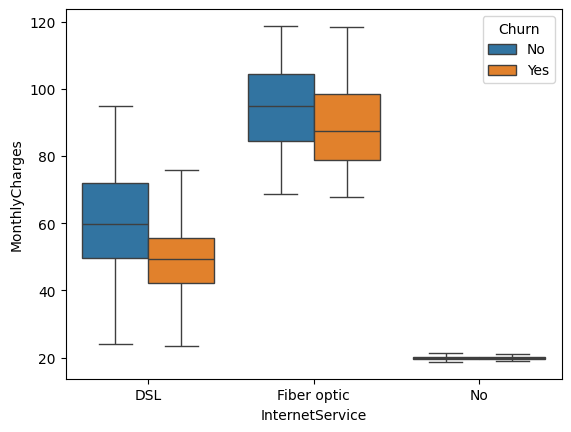

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def remove_outliers_group(df, group_col, target_col):
    clean_df = pd.DataFrame()
    for val in df[group_col].unique():
        temp = df[df[group_col] == val]
        Q1 = temp[target_col].quantile(0.25)
        Q3 = temp[target_col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        temp = temp[(temp[target_col] >= lower) & (temp[target_col] <= upper)]
        clean_df = pd.concat([clean_df, temp])
    return clean_df
df_clean = remove_outliers_group(df, 'InternetService', 'MonthlyCharges')
print("Before:", df.shape)
print("After:", df_clean.shape)
sns.boxplot(
    data=df_clean,
    x='InternetService',
    y='MonthlyCharges',
    hue='Churn',
    showfliers=False
)
plt.show()

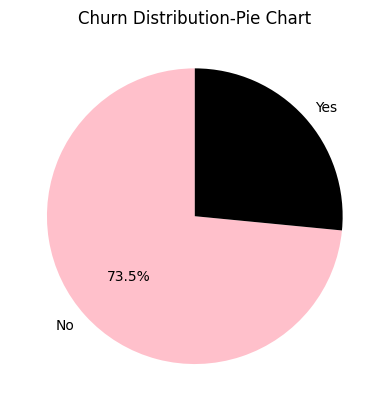

In [ ]:
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['pink','black'],startangle=90)
plt.title("Churn Distribution-Pie Chart")
plt.ylabel("")
plt.show()

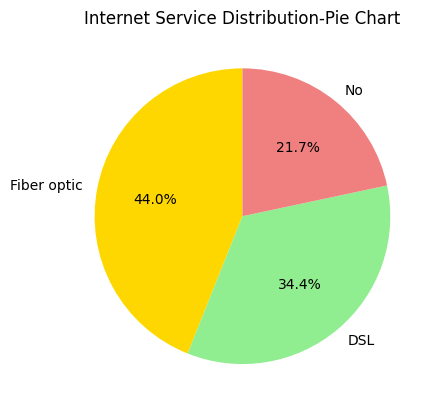

In [ ]:
df['InternetService'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['gold','lightgreen','lightcoral'])
plt.title("Internet Service Distribution-Pie Chart")
plt.ylabel("")
plt.show()

In [ ]:
df = df.drop('customerID', axis=1)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = X.select_dtypes(exclude='object')

In [ ]:
df.dtypes

,0
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
gender_Male,bool
Partner_Yes,bool
Dependents_Yes,bool
PhoneService_Yes,bool
MultipleLines_No phone service,bool
MultipleLines_Yes,bool


In [ ]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
start = time.time()
model.fit(X_train, y_train)
end = time.time()
efficiency = end - start
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy  :", accuracy)

Accuracy  : 0.7913413768630234


In [ ]:
precision = precision_score(y_test, y_pred)
print("Precision :", precision)

Precision : 0.660436137071651


In [ ]:
recall = recall_score(y_test, y_pred)
print("Recall    :", recall)

Recall    : 0.5340050377833753


In [ ]:
f1 = f1_score(y_test, y_pred)
print("F1 Score  :", f1)

F1 Score  : 0.5905292479108635


In [ ]:
print("Efficiency (Training Time in sec):", efficiency)

Efficiency (Training Time in sec): 0.060680389404296875


In [ ]:
print(X.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


Gender (Male/Female): 1
SeniorCitizen (0/1): 0
Partner (Yes/No): 0
Dependents (Yes/No): 0
Tenure: 1
PhoneService (Yes/No): 1
PaperlessBilling (Yes/No): 0
InternetService (DSL/Fiber optic/No): 2
Contract (Month-to-month/One year/Two year): 1
PaymentMethod (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)): 1
MonthlyCharges: 95
TotalCharges: 95

Customer will NOT churn


In [ ]:
gender = input("Gender (Male/Female): ")
SeniorCitizen = int(input("SeniorCitizen (0/1): "))
Partner = input("Partner (Yes/No): ")
Dependents = input("Dependents (Yes/No): ")
tenure = int(input("Tenure: "))
PhoneService = input("PhoneService (Yes/No): ")
PaperlessBilling = input("PaperlessBilling (Yes/No): ")
InternetService = input("InternetService (DSL/Fiber optic/No): ")
Contract = input("Contract (Month-to-month/One year/Two year): ")
PaymentMethod = input("PaymentMethod (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)): ")
MonthlyCharges = float(input("MonthlyCharges: "))
TotalCharges = float(input("TotalCharges: "))
new_data = pd.DataFrame(np.zeros((1, len(X.columns))), columns=X.columns)
new_data['tenure'] = tenure
new_data['MonthlyCharges'] = MonthlyCharges
new_data['TotalCharges'] = TotalCharges
new_data['SeniorCitizen'] = SeniorCitizen
if gender == "Male":
    if 'gender_Male' in new_data.columns:
        new_data['gender_Male'] = 1
if Partner == "Yes":
    if 'Partner_Yes' in new_data.columns:
        new_data['Partner_Yes'] = 1
if Dependents == "Yes":
    if 'Dependents_Yes' in new_data.columns:
        new_data['Dependents_Yes'] = 1
if PhoneService == "Yes":
    if 'PhoneService_Yes' in new_data.columns:
        new_data['PhoneService_Yes'] = 1
if PaperlessBilling == "Yes":
    if 'PaperlessBilling_Yes' in new_data.columns:
        new_data['PaperlessBilling_Yes'] = 1
col = f"InternetService_{InternetService}"
if col in new_data.columns:
    new_data[col] = 1
col = f"Contract_{Contract}"
if col in new_data.columns:
    new_data[col] = 1
col = f"PaymentMethod_{PaymentMethod}"
if col in new_data.columns:
    new_data[col] = 1
num_cols = ['tenure','MonthlyCharges','TotalCharges']
new_data[num_cols] = scaler.transform(new_data[num_cols])
prediction = model.predict(new_data)
if prediction[0] == 1:
    print("\nCustomer will CHURN")
else:
    print("\nCustomer will NOT churn")

Gender (Male/Female): 1
SeniorCitizen (0/1): 1
Partner (Yes/No): 0
Dependents (Yes/No): 0
Tenure: 2
PhoneService (Yes/No): 1
PaperlessBilling (Yes/No): 1
InternetService (DSL/Fiber optic/No): 1
Contract (Month-to-month/One year/Two year): 0
PaymentMethod (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)): 0
MonthlyCharges: 95
TotalCharges: 185

Customer will CHURN
